In [77]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Базовая работа с изображением

In [78]:
image = cv2.imread('sar_2_color.jpg')

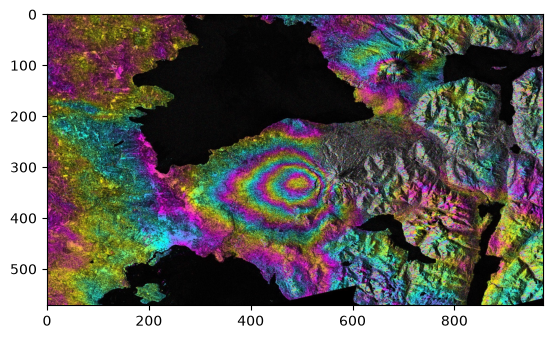

In [79]:
plt.imshow(image)

In [80]:
image.shape # h,w,c

(572, 974, 3)

In [81]:
image[250,250] # b,g,r

array([12, 12, 12], dtype=uint8)

In [82]:
# ROI
img_roi = image[100:200, 500:700]

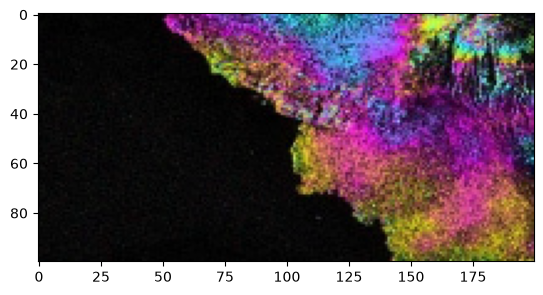

In [83]:
plt.imshow(img_roi)

In [84]:
b,g,r = cv2.split(image)

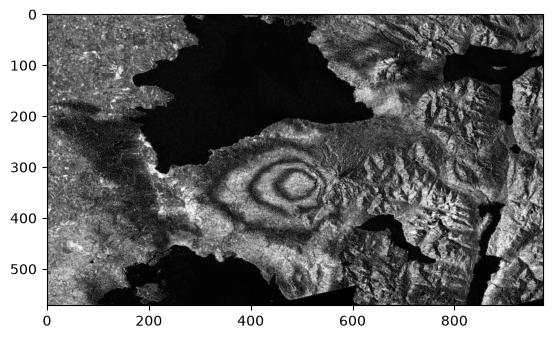

In [85]:
plt.imshow(b, cmap = 'gray')

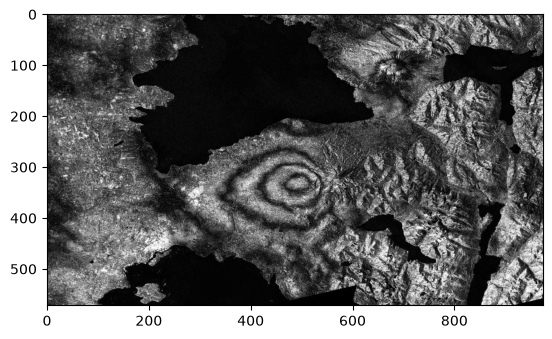

In [86]:
plt.imshow(g, cmap = 'gray')

In [87]:
# alternative approach
b = image[:,:,0]

In [88]:
import copy

image2 = copy.deepcopy(image)

In [89]:
image2[50:100,50:100] = [0,0,0]

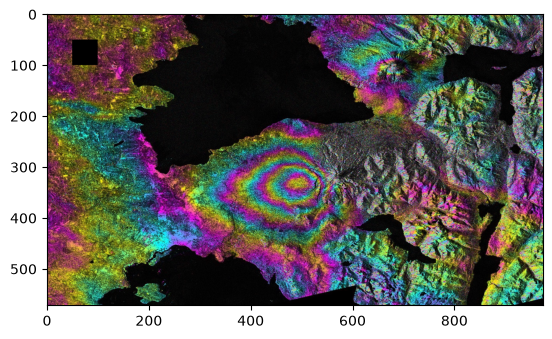

In [90]:
plt.imshow(image2)

In [91]:
# empty image
image_template = np.zeros(image.shape,np.uint8)

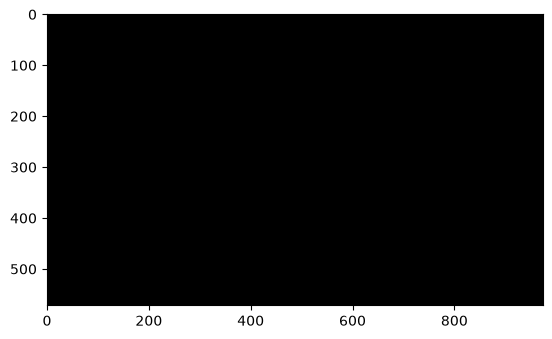

In [92]:
plt.imshow(image_template)

# Конвертация цветовых моделей

In [93]:
image_template[0,0]

array([0, 0, 0], dtype=uint8)

In [94]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

In [95]:
image_gray[0,0]

np.uint8(40)

In [96]:
image_gray.shape

(572, 974)

In [97]:
image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV) 

In [98]:
image_hsv.shape

(572, 974, 3)

In [99]:
image_hsv[0,0]

array([117, 143,  75], dtype=uint8)

In [100]:
image[0,0]

array([75, 37, 33], dtype=uint8)

In [101]:
image_lab = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)

In [102]:
image_lab[0,0]

array([ 42, 139, 104], dtype=uint8)

# Пороговая фильтрация

In [103]:
_,thresh1 = cv2.threshold(image_gray,200,255,cv2.THRESH_BINARY)

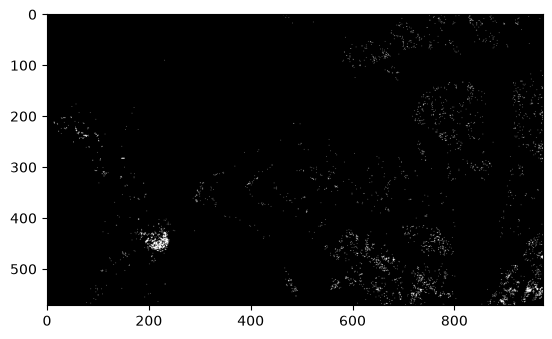

In [104]:
plt.imshow(thresh1, cmap='gray')

In [105]:
thresh1[thresh1==100].sum()

np.uint64(0)

# Построение гистограммы

In [106]:
histSize = 256
histRange = (0, 256)
accumulate = False

b_hist = cv2.calcHist([b], [0], None, [histSize], histRange, accumulate=accumulate)

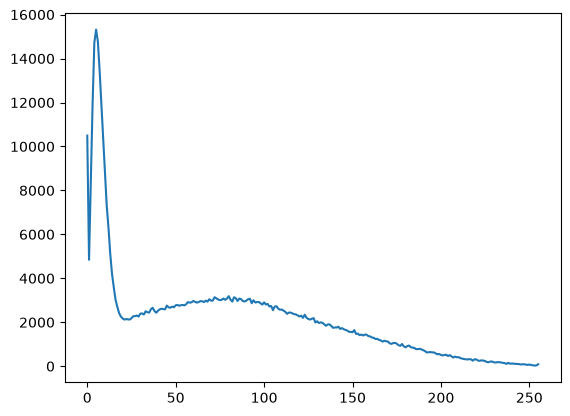

In [107]:
plt.plot(b_hist)

In [108]:
b_hist_cum = b_hist.cumsum()

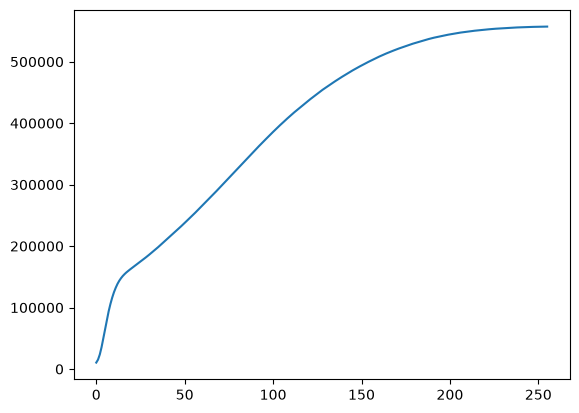

In [109]:
plt.plot(b_hist_cum)

In [110]:
b_hist_norm = b_hist /  (image.shape[0] * image.shape[1])

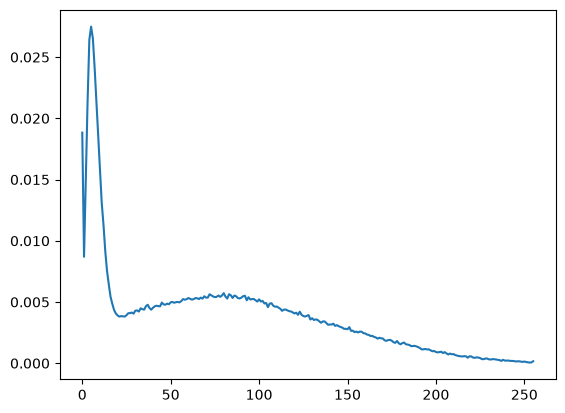

In [111]:
plt.plot(b_hist_norm)

# Сравнение двух изображений

In [112]:
from skimage.metrics import structural_similarity, mean_squared_error

(ssim, diff) = structural_similarity(image_gray, image_gray, full=True)
diff = (diff * 255).astype("uint8")
print("SSIM: {}".format(ssim))

SSIM: 1.0


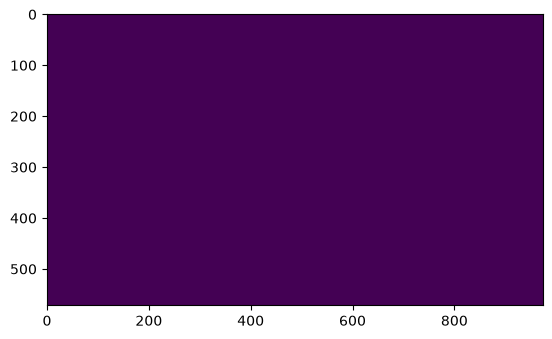

In [113]:
plt.imshow(diff)

In [114]:
mse = mean_squared_error(image_gray, image_gray)
mse

np.float64(0.0)

# Статистические характеристики изображений

In [115]:
mean = image_gray.mean()

In [116]:
std = image_gray.std()

In [117]:
print(mean,std)

67.41225535245043 52.01619187595963


In [118]:
eq_gray = cv2.equalizeHist(image_gray)

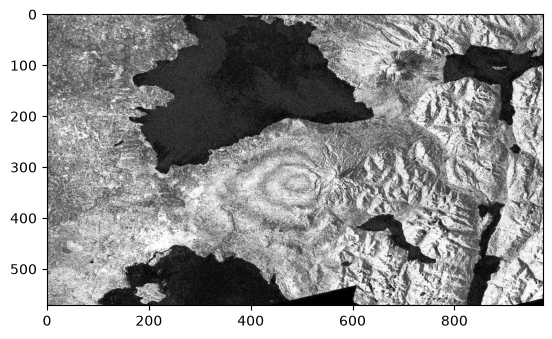

In [119]:
plt.imshow(eq_gray, cmap="gray")


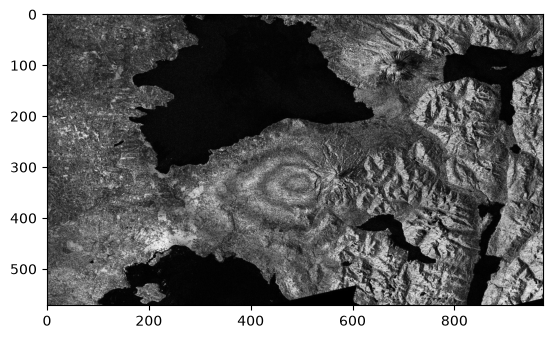

In [120]:
plt.imshow(image_gray, cmap="gray")

In [121]:
# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg. 
# 2. постройте гистограмму
# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.
# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.
# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.
# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.
# Для каждого решения - напечатайте результат


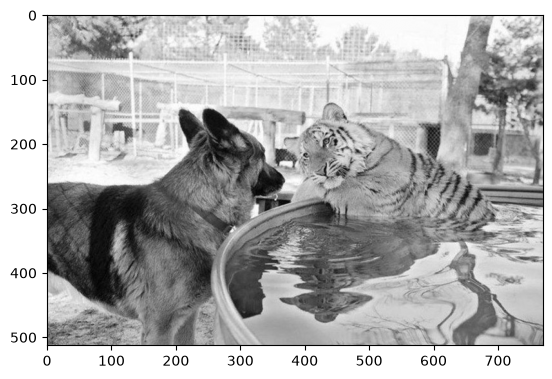

In [122]:
img = cv2.imread('vot-takaja-vot-mem.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')
plt.show()

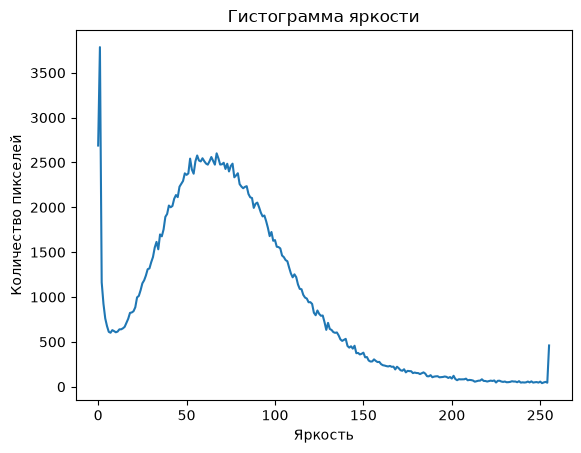

In [123]:
hist = cv2.calcHist([image_gray_1], [0], None, [256], [0, 256])

plt.figure()
plt.plot(hist)
plt.title('Гистограмма яркости')
plt.xlabel('Яркость')
plt.ylabel('Количество пикселей')
plt.show()

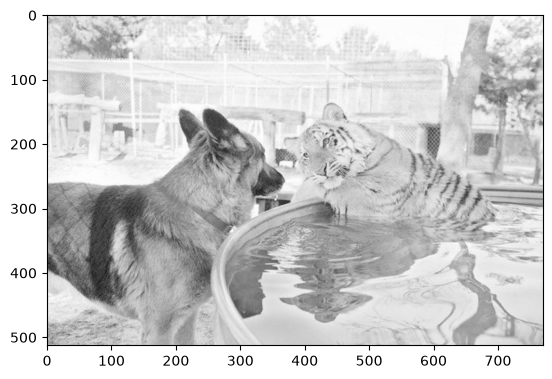

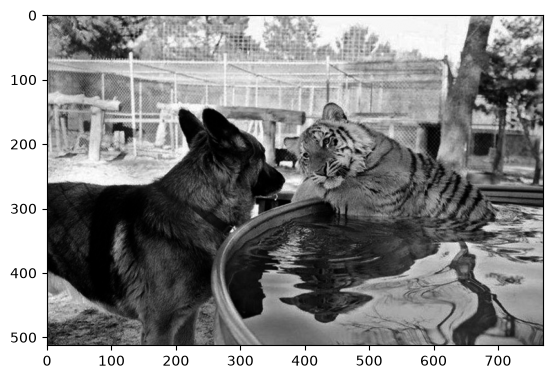

In [124]:
def gamma(img, g):
    return np.uint8(np.power(img / 255.0, g) * 255)

img_gamma_lt1 = gamma(img, 0.5)
img_gamma_gt1 = gamma(img, 2.0)
plt.imshow(img_gamma_lt1, cmap='gray'); plt.show()
plt.imshow(img_gamma_gt1, cmap='gray'); plt.show()

In [125]:
print("gamma<1:", mean_squared_error(img, img_gamma_lt1), structural_similarity(img, img_gamma_lt1))
print("gamma>1:", mean_squared_error(img, img_gamma_gt1), structural_similarity(img, img_gamma_gt1))

gamma<1: 1695.4471861471861 0.87946789304437
gamma>1: 2344.3923647502593 0.7913956251069639


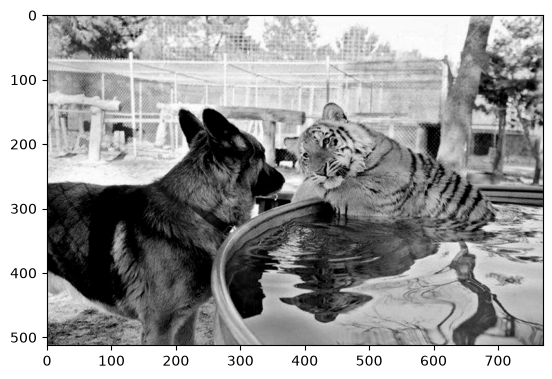

In [126]:
corrected = (img - img.mean()) / img.std() * eq_gray.std() + eq_gray.mean()
corrected = np.clip(corrected, 0, 255).astype(np.uint8)
plt.imshow(corrected, cmap='gray'); plt.show()

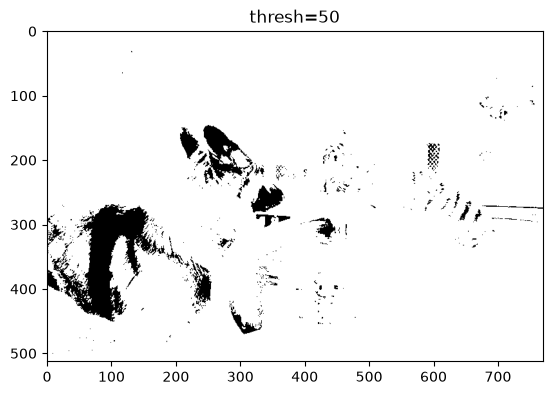

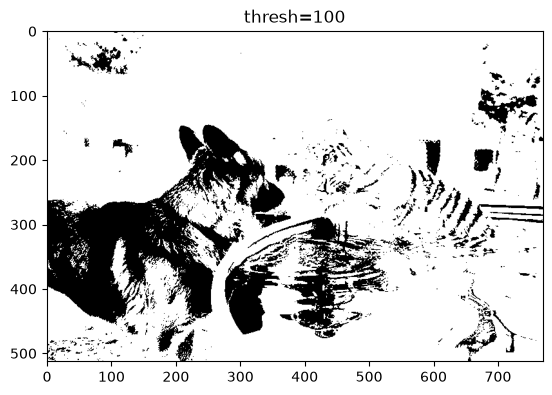

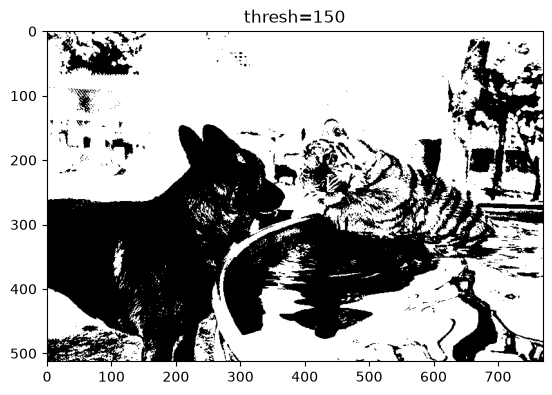

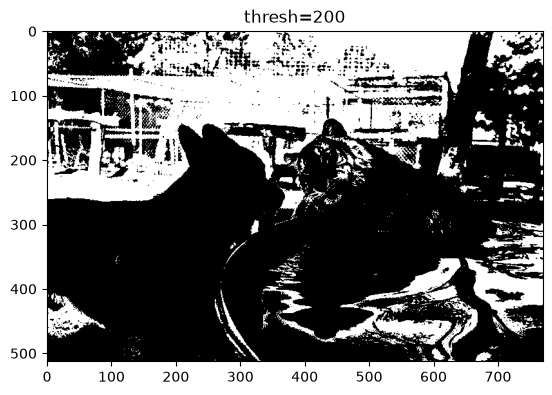

In [127]:
for t in [50, 100, 150, 200]:
    _, th = cv2.threshold(img, t, 255, cv2.THRESH_BINARY)
    plt.imshow(th, cmap='gray'); plt.title(f'thresh={t}'); plt.show()